# Demo 3.1: **Phân tích khám phá DL (EDA)**
<u>Nội dung</u>:
1. Phân tích ĐƠN biến
2. Phân tích ĐA biến

<u>Cập nhật</u>: **09/2026**

---
### **MÔI TRƯỜNG TRIỂN KHAI ỨNG DỤNG**
---

In [1]:
## Kết nối Google Drive
from google.colab import drive
drive.mount('/content/gdrive')

folder = '/content/gdrive/My Drive/Edu/1. UEH/Lap trinh phan tich DL/Demo'

Mounted at /content/gdrive


In [52]:
## Thư viện tính toán
import numpy                  as np
import pandas                 as pd
import scipy.stats            as scp
import warnings
warnings.filterwarnings('ignore')

## Thư viện biểu diễn trực quan
import matplotlib.pyplot      as plt
import seaborn                as sbn
from tabulate                 import tabulate

---
### **1. Phân tích ĐƠN biến**
---

In [74]:
## Các tập tin dữ liệu
df_ins  = pd.read_excel(folder + '/Data/Data.xls', sheet_name = 'Insurance')
df_iris = pd.read_excel(folder + '/Data/Data.xls', sheet_name = 'Iris')
df_ttn  = pd.read_excel(folder + '/Data/Data.xls', sheet_name = 'Titanic')

#####*Thông tin về tập tin DL (metadata)*

In [75]:
## Thông tin chung
print(df_ins.info(), '\n----------\n')

## Các cột
cat_cols = df_ins.select_dtypes(include = ['object', 'category']).columns.tolist()
num_cols = df_ins.select_dtypes(include = ['number']).columns.tolist()
print('Các cột dữ liệu kiểu PHÂN LOẠI :', cat_cols)
print('Các cột dữ liệu kiểu SỐ        :', num_cols)

print('Kích thước (số dòng, số cột)   :', df_ins.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None 
----------

Các cột dữ liệu kiểu PHÂN LOẠI : ['sex', 'smoker', 'region']
Các cột dữ liệu kiểu SỐ        : ['age', 'bmi', 'children', 'charges']
Kích thước (số dòng, số cột)   : (1338, 7)


#####*Phát hiện những giá trị bị thiếu (Null) thuộc các kiểu dữ liệu*

*** Số giá trị bị thiếu của các cột trong Titanic:
+-----------+-----------------+
| feature   |   missing count |
|-----------+-----------------|
| Age       |             177 |
| Cabin     |             687 |
| Embarked  |               2 |
| Fare      |               2 |
| Sex       |              25 |
+-----------+-----------------+


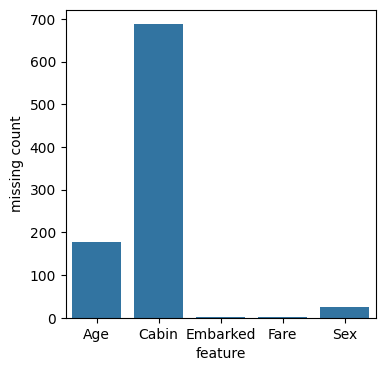

In [78]:
## Giá trị bị thiếu của các cột trong Titanic
print('*** Số giá trị bị thiếu của các cột trong Titanic:')
missing_series = len(df_ttn) - df_ttn.count()
missing_df_ttn = missing_series.reset_index()  # chuyển thành dataframe
missing_df_ttn.columns = ['feature', 'missing count']

missing_df_ttn = missing_df_ttn.sort_values(by = 'feature', ascending = True)
missing_df_ttn = missing_df_ttn[missing_df_ttn['missing count'] > 0]  # chọn lọc

missing_df_ttn.set_index('feature', inplace = True)

## Hình thức bảng biểu
print(tabulate(missing_df_ttn, headers = 'keys', tablefmt = 'psql'))

## Biểu diễn trực quan
plt.figure(figsize = (4, 4))
sbn.barplot(x = missing_df_ttn.index, y = missing_df_ttn['missing count'])
plt.show()

In [80]:
## Sử dụng các phương thức isnull(), notnull()
print('Số giá trị bị thiếu của cột Age:', len(df_ttn[df_ttn.Age.isnull()]))

Số giá trị bị thiếu của cột Age: 177


#####1.2 *Phát hiện outliers*

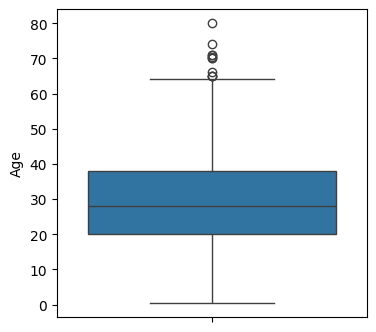

In [81]:
## Quan sát outlier(s) dựa trên Boxplot
plt.figure(figsize = (4, 4))
sbn.boxplot(df_ttn['Age'])

plt.show()

In [82]:
## Áp dụng quy tắc 3-Sigma
mean, std = np.mean(df_ttn['Age']), np.std(df_ttn['Age'], ddof = 1)
print(f'Giá trị trung bình   : {mean:.4f}')
print(f'Giá trị độ lệch chuẩn: {std:.4f}')
print('Các giá trị outliers :', df_ttn[np.abs(df_ttn['Age'] - mean) > 3 * std]['Age'].values)

Giá trị trung bình   : 29.6991
Giá trị độ lệch chuẩn: 14.5265
Các giá trị outliers : [80. 74.]


#####1.3 *Phân tích hình dáng phân phối*

Độ nghiêng : 0.2837
Độ nhọn    : -0.0550


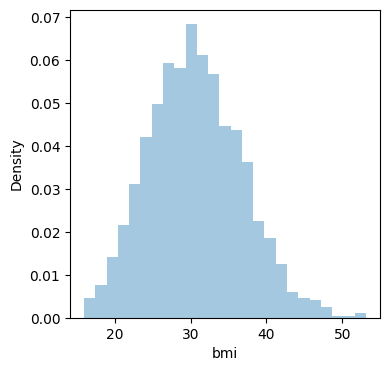

In [85]:
## Độ nghiêng, độ nhọn của phân phối Insurance.bmi
print(f'Độ nghiêng : {scp.skew(df_ins['bmi']):.4f}')
print(f'Độ nhọn    : {scp.kurtosis(df_ins['bmi']):.4f}')

## Biểu diễn trực quan
plt.figure(figsize = (4, 4))
plt.xlabel('bmi')
plt.ylabel('Density')
sbn.distplot(df_ins['bmi'], kde = False, norm_hist = True)
plt.show()

---
### **2. Phân tích ĐA biến**
---

#####2.1 *Phân tích tương quan*

             sepallength  sepalwidth  petallength  petalwidth
sepallength     1.000000   -0.109369     0.871754    0.817954
sepalwidth     -0.109369    1.000000    -0.420516   -0.356544
petallength     0.871754   -0.420516     1.000000    0.962757
petalwidth      0.817954   -0.356544     0.962757    1.000000


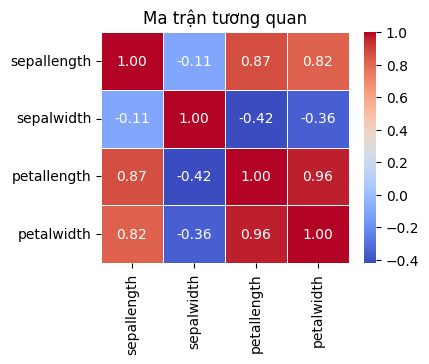

In [88]:
## Ma trận tương quan (Pearson correlation matrix)
corr_matrix = df_iris.corr(numeric_only = True)
print(corr_matrix)

## Biểu đồ heatmap
plt.figure(figsize = (4, 3))
sbn.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f', linewidths = 0.5)
plt.title('Ma trận tương quan')
plt.show()